## Pré-processing et Feature Engineering

## Chargement des données

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import warnings
from category_encoders import TargetEncoder

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.model_selection import learning_curve

from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)
pd.set_option("display.max_columns", None)

In [4]:
df_2014 = pd.read_csv(
    "../data/co2_2014.csv",
    encoding="latin1",
    sep=";"
)

df_2014.head()

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,typ_boite_nb_rapp,conso_urb,conso_exurb,conso_mixte,co2,co_typ_1,hc,nox,hcnox,ptcl,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12,147,M 6,"11,30000019","5,800000191","7,800000191",182.0,"0,647000015","0,052000001","0,032000002",NaN,"0,002",1505,1505,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
1,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000H341,939BXN1B53C,ES,non,12,147,M 6,"11,5",6,8,186.0,"0,647000015","0,052000001","0,032000002",NaN,"0,002",1555,1555,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7,100,M 6,"6,599999905","4,199999809","5,099999905",134.0,"0,066",NaN,"0,149000004","0,174999997","0,001",1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7,100,M 6,"6,599999905","4,199999809","5,099999905",134.0,"0,066",NaN,"0,149000004","0,174999997","0,001",1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9,125,M 6,"6,900000095","4,300000191","5,300000191",139.0,"0,059999999",NaN,"0,164000005","0,193000004","0,001",1565,1565,715/2007*692/2008EURO5,mars-14,BERLINE,MOY-SUPER,NaN,NaN,NaN,NaN



## État initial du dataset

In [5]:

df_2014.shape

(55044, 30)

In [6]:
df_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          55044 non-null  str    
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          55001 non-null  str    
 12  conso_exurb        55001 non-null  str    
 13  conso_mixte        55010 non-null  str    
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  str    
 16  hc                 9773 non-null 

Le jeu de données contient 55 044 observations et 30 variables.

Les variables décrivent les caractéristiques techniques des véhicules homologués en France en 2014 : marque, modèle, type de carburant, puissance, consommation, masse, norme environnementale et émissions de CO₂.

Avant toute modélisation, une phase de prétraitement est réalisée afin de nettoyer les données, traiter les valeurs manquantes et préparer le jeu de données pour les étapes suivantes. Conformément aux bonnes pratiques, les transformations apprenant des informations à partir des données (imputation, encodage ou standardisation) seront ajustées uniquement sur le jeu d'entraînement avant d'être appliquées au jeu de test, afin d'éviter tout risque de data leakage.

## Analyse des valeurs manquantes

In [7]:
(df_2014.isnull().mean() * 100).sort_values(ascending=False)

Unnamed: 27          100.000000
Unnamed: 26          100.000000
Unnamed: 29          100.000000
Unnamed: 28          100.000000
date_maj              94.101083
hc                    82.245113
hcnox                 17.963811
ptcl                   4.865199
nox                    0.287043
co_typ_1               0.287043
champ_v9               0.110820
conso_urb              0.078119
conso_exurb            0.078119
conso_mixte            0.061769
co2                    0.061769
typ_boite_nb_rapp      0.000000
puiss_admin_98         0.000000
hybride                0.000000
cod_cbr                0.000000
dscom                  0.000000
cnit                   0.000000
tvv                    0.000000
lib_mod_doss           0.000000
lib_mrq                0.000000
lib_mod                0.000000
puiss_max              0.000000
masse_ordma_max        0.000000
masse_ordma_min        0.000000
gamme                  0.000000
Carrosserie            0.000000
dtype: float64

L'analyse des valeurs manquantes met en évidence plusieurs variables fortement incomplètes.

Les colonnes `Unnamed: 26` à `Unnamed: 29` sont entièrement vides, tandis que la variable `date_maj` présente plus de 94 % de valeurs manquantes. Parmi les variables environnementales, `hc` affiche plus de 82 % de données manquantes et `hcnox` près de 18 %.

À l'inverse, la majorité des autres variables sont quasiment complètes, avec moins de 1 % de valeurs manquantes.

Ces résultats permettent d'orienter les choix de prétraitement. Les variables très fortement incomplètes seront supprimées lorsqu'elles ne présentent pas d'intérêt pour la modélisation, tandis que les variables comportant peu de valeurs manquantes feront l'objet d'un traitement adapté afin de préserver un maximum d'informations.

## Suppression des colonnes vides et peu exploitables

In [8]:
colonnes_a_supprimer = [
    'Unnamed: 26',
    'Unnamed: 27',
    'Unnamed: 28',
    'Unnamed: 29',
    'date_maj'
]

df_2014 = df_2014.drop(columns=colonnes_a_supprimer)

df_2014.shape

(55044, 25)


Les colonnes Unnamed: 26 à Unnamed: 29 ont été supprimées car elles étaient entièrement vides et n'apportaient aucune information exploitable.

La variable date_maj a également été retirée du jeu de données. Avec plus de 94 % de valeurs manquantes et sans pouvoir explicatif direct pour la prédiction des émissions de CO₂, son exploitation apparaissait peu pertinente pour la suite du projet.

Le dataset passe ainsi de 30 à 25 variables, tout en conservant les 55 044 observations initiales.

## Traitement des variables fortement incomplètes

In [9]:
df_2014 = df_2014.drop(columns=['hc', 'hcnox'])

df_2014.shape

(55044, 23)

Les variables hc et hcnox présentent respectivement plus de 82 % et près de 18 % de valeurs manquantes.

La variable hc a été supprimée en raison de son très faible niveau de complétude, rendant toute imputation peu pertinente. La variable hcnox a également été retirée afin de simplifier le jeu de données et de privilégier des variables environnementales plus complètes et directement exploitables pour la modélisation.

La variable ptcl, bien qu'incomplète, a été conservée car son taux de valeurs manquantes reste limité (moins de 5 %) et elle conserve un intérêt potentiel pour l'analyse des émissions polluantes.

Le dataset passe ainsi de 25 à 23 variables.

## Conversion des variables numériques

Certaines variables quantitatives ont été importées sous forme de chaînes de caractères en raison de l'utilisation de la virgule comme séparateur décimal. Elles sont converties au format numérique afin de permettre les calculs statistiques, les traitements de prétraitement et les futures étapes de modélisation.

In [10]:
colonnes_numeriques = [
    'puiss_max',
    'conso_urb',
    'conso_exurb',
    'conso_mixte',
    'co_typ_1',
    'nox',
    'ptcl'
]

for col in colonnes_numeriques:
    df_2014[col] = (
        df_2014[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )

    df_2014[col] = pd.to_numeric(df_2014[col], errors='coerce')

In [11]:
df_2014.info()

<class 'pandas.DataFrame'>
RangeIndex: 55044 entries, 0 to 55043
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lib_mrq            55044 non-null  str    
 1   lib_mod_doss       55044 non-null  str    
 2   lib_mod            55044 non-null  str    
 3   dscom              55044 non-null  str    
 4   cnit               55044 non-null  str    
 5   tvv                55044 non-null  str    
 6   cod_cbr            55044 non-null  str    
 7   hybride            55044 non-null  str    
 8   puiss_admin_98     55044 non-null  int64  
 9   puiss_max          55044 non-null  float64
 10  typ_boite_nb_rapp  55044 non-null  str    
 11  conso_urb          55001 non-null  float64
 12  conso_exurb        55001 non-null  float64
 13  conso_mixte        55010 non-null  float64
 14  co2                55010 non-null  float64
 15  co_typ_1           54886 non-null  float64
 16  nox                54886 non-null

Les variables concernées ont été correctement converties au format numérique (float64), ce qui permettra leur utilisation dans les analyses statistiques et les algorithmes de modélisation.

Cette conversion a également permis d'identifier d'éventuelles valeurs invalides, désormais représentées sous forme de valeurs manquantes (NaN), qui seront traitées lors des étapes suivantes du prétraitement.

## Choix de la méthode d'imputation

Les variables ptcl, nox et co_typ_1 présentent un faible taux de valeurs manquantes (inférieur à 5 %). Afin de conserver l'ensemble des observations tout en limitant les biais liés aux données manquantes, plusieurs stratégies d'imputation ont été étudiées.

Une première approche consistait à réaliser une imputation par marque de véhicule. Cette solution n'a toutefois pas été retenue en raison de la forte disparité des effectifs entre les marques. Certaines sont représentées par plusieurs dizaines de milliers de véhicules, tandis que d'autres ne comptent que quelques dizaines d'observations, rendant les médianes calculées peu robustes pour les marques les moins représentées.

Une seconde approche reposait sur une imputation par type de carburant. Cette stratégie apparaît particulièrement pertinente pour certaines variables environnementales, les émissions polluantes étant directement liées à la motorisation des véhicules. Une analyse de la répartition des catégories de carburant, des effectifs associés et des médianes par carburant a donc été réalisée afin d'évaluer cette hypothèse.

Enfin, une troisième approche consistait à utiliser la médiane globale du jeu de données. Cette méthode simple et robuste permet de limiter l'influence des valeurs extrêmes tout en conservant l'ensemble des observations.

Les analyses réalisées montrent que les variables nox et co_typ_1 présentent des différences importantes selon le type de carburant, tandis que les médianes de ptcl restent très proches entre les principales catégories. En conséquence, une imputation conditionnelle par carburant a été retenue pour nox et co_typ_1, tandis qu'une imputation par la médiane globale a été privilégiée pour ptcl.

In [12]:
# Répartition des carburants
df_2014['cod_cbr'].value_counts()

cod_cbr
GO       49311
ES        5169
EH         298
GH          81
EL          34
ES/GN       32
GN/ES       32
ES/GP       23
GP/ES       23
GN          21
FE          10
EE           9
GL           1
Name: count, dtype: int64

In [13]:
# Médianes NOx par carburant
df_2014.groupby('cod_cbr')['nox'].median().sort_values()

cod_cbr
EE       0.003
EH       0.006
ES/GP    0.018
FE       0.020
GP/ES    0.026
ES       0.030
GN/ES    0.031
GN       0.032
ES/GN    0.036
GL       0.036
GH       0.061
GO       0.214
EL         NaN
Name: nox, dtype: float64

In [14]:
# Médianes PTCL par carburant
df_2014.groupby('cod_cbr')['ptcl'].median().sort_values()

cod_cbr
GL       0.000
EE       0.001
ES       0.001
EH       0.001
FE       0.001
GH       0.001
GO       0.001
GN       0.007
EL         NaN
ES/GN      NaN
ES/GP      NaN
GN/ES      NaN
GP/ES      NaN
Name: ptcl, dtype: float64

In [15]:
# Médianes CO par carburant
df_2014.groupby('cod_cbr')['co_typ_1'].median().sort_values()

cod_cbr
GL       0.020
GO       0.100
EE       0.132
EH       0.187
GH       0.222
ES       0.238
GN/ES    0.258
ES/GN    0.305
ES/GP    0.360
GN       0.370
GP/ES    0.382
FE       0.632
EL         NaN
Name: co_typ_1, dtype: float64

In [16]:
df_2014.groupby('cod_cbr')[['nox', 'co_typ_1']].count()

,nox,co_typ_1
cod_cbr,,
EE,9,9
EH,298,298
EL,0,0
ES,5096,5096
ES/GN,20,20
ES/GP,23,23
FE,10,10
GH,81,81
GL,1,1


## Analyse des résultats

L'analyse des médianes par carburant met en évidence des différences importantes pour les variables nox et co_typ_1, notamment entre les véhicules diesel (GO) et essence (ES).

Pour la variable nox, la médiane observée pour les véhicules diesel (0,214) est significativement supérieure à celle des véhicules essence (0,030). Une différence notable est également observée pour co_typ_1, avec des médianes respectives de 0,100 pour le diesel et 0,238 pour l'essence.

À l'inverse, les médianes de ptcl sont quasiment identiques quel que soit le carburant considéré, ce qui suggère une faible influence de cette variable de regroupement.

Les catégories majoritaires (GO et ES) disposent d'effectifs très élevés, garantissant la robustesse des médianes calculées. À l'inverse, certaines catégories très peu représentées (par exemple GL, FE ou EE) doivent être interprétées avec davantage de prudence. Enfin, la catégorie EL ne comporte aucune valeur disponible pour les variables nox et co_typ_1.

Ces résultats justifient le recours à une imputation conditionnelle par carburant pour les variables nox et co_typ_1, tandis qu'une imputation par la médiane globale est conservée pour ptcl.

Conformément aux bonnes pratiques de prétraitement, cette stratégie d'imputation sera appliquée uniquement après la séparation des jeux d'entraînement et de test, afin d'éviter tout risque de data leakage.

## Analyse des modalités rares

In [17]:
df_2014['lib_mrq'].value_counts(normalize=True) * 100

lib_mrq
MERCEDES        65.801904
VOLKSWAGEN      24.836494
FIAT             0.930165
BMW              0.841145
OPEL             0.724875
LEXUS            0.654022
AUDI             0.634038
FORD             0.541385
NISSAN           0.523218
CITROEN          0.399680
ALFA-ROMEO       0.332461
PEUGEOT          0.316111
RENAULT          0.290677
TOYOTA           0.254342
SKODA            0.237991
MINI             0.227091
PORSCHE          0.198023
SEAT             0.196207
VOLVO            0.196207
ASTON MARTIN     0.141705
CHEVROLET        0.138071
JEEP             0.134438
LAND ROVER       0.134438
KIA              0.121721
LANCIA           0.105370
HONDA            0.101737
SMART            0.094470
HYUNDAI          0.092653
MITSUBISHI       0.079936
MAZDA            0.074486
JAGUAR           0.070852
CADILLAC         0.069036
LAMBORGHINI      0.065402
DACIA            0.052685
SUZUKI           0.052685
BENTLEY          0.047235
FERRARI          0.045418
MASERATI         0.043601
SUBA

L'analyse de la variable lib_mrq met en évidence la présence de nombreuses modalités rares représentant moins de 0,5 % des observations. Compte tenu de l'objectif de ce premier prétraitement, aucune fusion de modalités n'a été réalisée à ce stade. Cette transformation pourra être envisagée ultérieurement si la variable est retenue pour la modélisation.

## Création de nouvelles variables

In [18]:
df_2014['rapport_puissance_masse'] = (
    df_2014['puiss_max'] /
    df_2014['masse_ordma_min']
)

In [19]:
df_2014['rapport_puissance_masse'].describe()

count    55044.000000
mean         0.057802
std          0.024929
min          0.010776
25%          0.045746
50%          0.052016
75%          0.059259
max          0.373802
Name: rapport_puissance_masse, dtype: float64

In [20]:
df_2014[['rapport_puissance_masse', 'co2']].corr()

,rapport_puissance_masse,co2
rapport_puissance_masse,1.00000,0.08878
co2,0.08878,1.00000


La corrélation linéaire observée entre cette variable et les émissions de CO₂ reste faible (0,089). Dans le cadre de cette première approche, cette variable n'apporte pas de gain explicatif suffisant et n'a donc pas été retenue pour la suite du prétraitement.

## Décision retenue

Les analyses précédentes montrent que le rapport puissance/masse présente une corrélation linéaire très faible avec les émissions de CO₂. Cette variable n'apportant pas de pouvoir explicatif supplémentaire dans cette première approche, elle est retirée du jeu de données afin de conserver un prétraitement simple et pertinent.

In [21]:
df_2014.drop(columns=['rapport_puissance_masse'], inplace=True)

## Vérification

In [22]:
'rapport_puissance_masse' in df_2014.columns

False

La faible corrélation observée avec les émissions de CO₂ (≈ 0,089) ne justifie pas le maintien de cette variable dans le jeu de données. La vérification confirme qu'elle a bien été supprimée avant les étapes de modélisation.

In [23]:
# Création du ratio puissance / masse maximale
df_2014["rapport_puissance_masse_max"] = (
    df_2014["puiss_max"] / df_2014["masse_ordma_max"]
)

In [24]:
df_2014["rapport_puissance_masse_max"].describe()

count    55044.000000
mean         0.053289
std          0.026310
min          0.010776
25%          0.040340
50%          0.046154
75%          0.057637
max          0.373802
Name: rapport_puissance_masse_max, dtype: float64

In [25]:
df_2014[["rapport_puissance_masse_max", "co2"]].corr()

,rapport_puissance_masse_max,co2
rapport_puissance_masse_max,1.000000,0.053839
co2,0.053839,1.000000


Un second ratio basé sur la masse maximale du véhicule (puiss_max / masse_ordma_max) a également été évalué. La corrélation linéaire observée avec les émissions de CO₂ (0,054) étant encore plus faible que celle obtenue avec la masse minimale, cette variable n'a pas été retenue pour la suite du prétraitement.

## Décision retenue

In [26]:
df_2014.drop(columns=["rapport_puissance_masse_max"], inplace=True)

## Vérification

In [27]:
"rapport_puissance_masse_max" in df_2014.columns

False

## Détection des valeurs aberrantes

### Approche graphique

Les valeurs aberrantes (outliers) correspondent à des observations dont les valeurs s'écartent fortement du reste de la distribution.

Leur identification est importante car elles peuvent influencer les analyses statistiques et les performances des modèles de machine learning. Dans le cas présent, l'objectif est d'identifier les éventuelles valeurs extrêmes présentes dans les principales variables quantitatives du dataset afin d'évaluer leur pertinence métier avant toute décision de traitement.

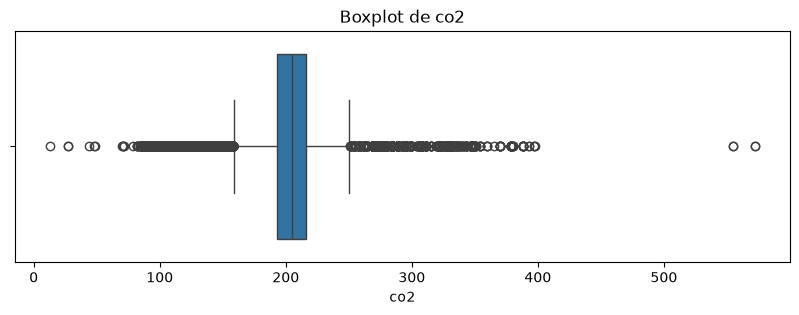

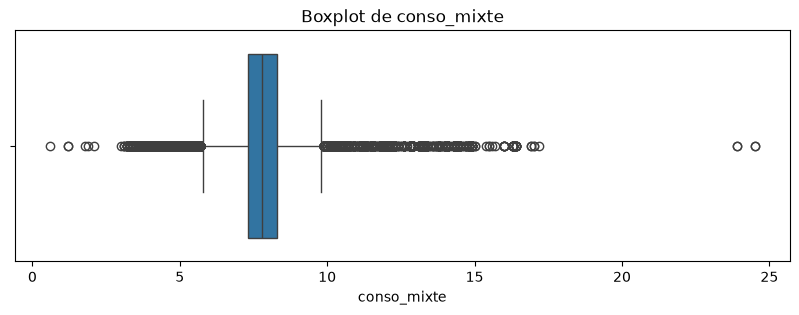

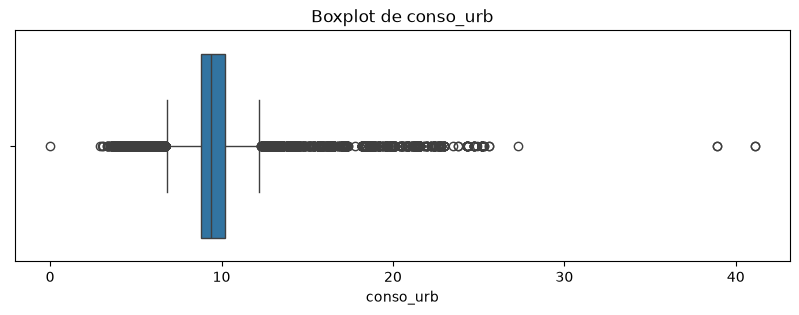

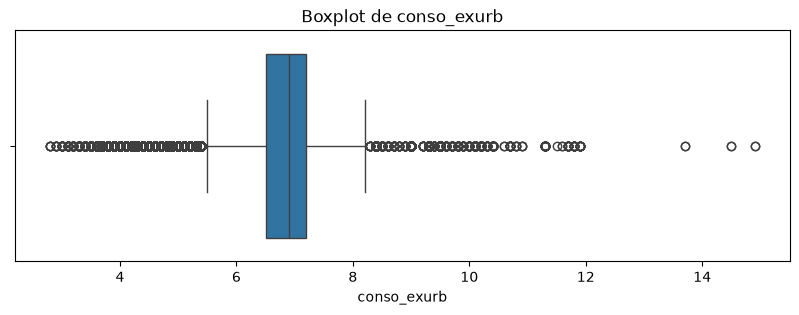

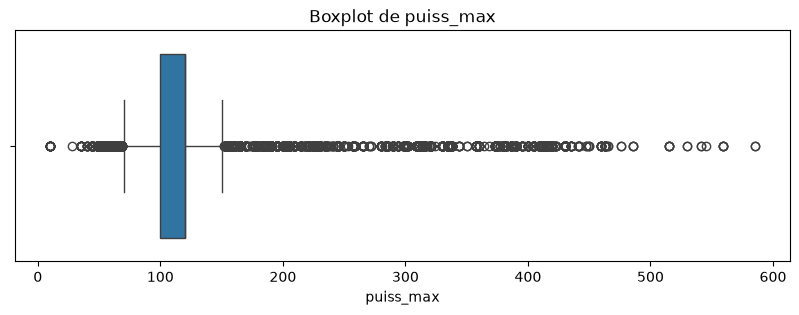

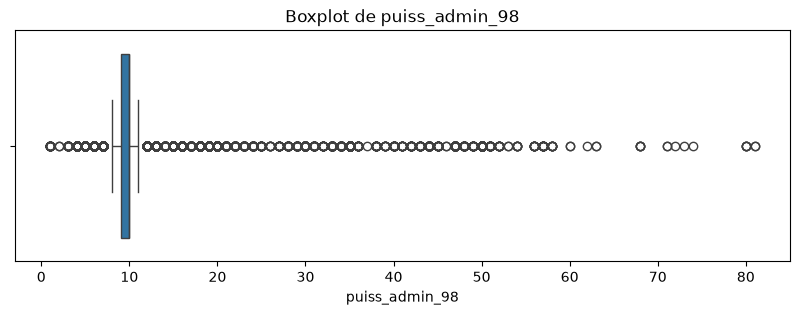

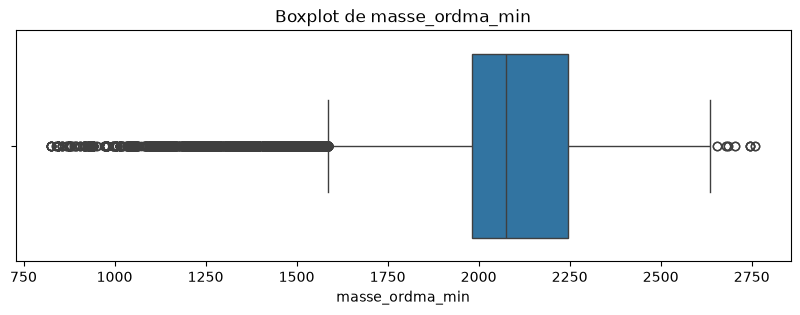

In [28]:
colonnes_numeriques = [
    'co2',
    'conso_mixte',
    'conso_urb',
    'conso_exurb',
    'puiss_max',
    'puiss_admin_98',
    'masse_ordma_min'
]

for col in colonnes_numeriques:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=df_2014[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

### Approche statistique (méthode de l'IQR)

Afin de compléter l'analyse graphique réalisée à l'aide des boxplots, une détection statistique des valeurs aberrantes est effectuée à l'aide de la méthode de l'intervalle interquartile (IQR).

Cette méthode repose sur le calcul des premier (Q1) et troisième (Q3) quartiles de chaque variable. Les observations situées en dehors des bornes définies par **Q1 − 1,5 × IQR** et **Q3 + 1,5 × IQR**, où **IQR = Q3 − Q1**, sont considérées comme des valeurs aberrantes.

L'objectif est de confirmer, de manière quantitative, la présence de valeurs extrêmes observées lors de l'analyse graphique et d'évaluer leur importance dans les principales variables numériques du jeu de données.

In [29]:
variables = [
    "co2",
    "conso_mixte",
    "conso_urb",
    "conso_exurb",
    "puiss_max",
    "puiss_admin_98",
    "masse_ordma_min"
]

resultats_iqr = []

for var in variables:
    Q1 = df_2014[var].quantile(0.25)
    Q3 = df_2014[var].quantile(0.75)
    IQR = Q3 - Q1

    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR

    masque = (df_2014[var] < borne_inf) | (df_2014[var] > borne_sup)

    nb_outliers = masque.sum()
    pourcentage = nb_outliers / len(df_2014) * 100

    resultats_iqr.append({
        "Variable": var,
        "Nombre d'outliers": nb_outliers,
        "% d'outliers": round(pourcentage, 2)
    })

pd.DataFrame(resultats_iqr)

,Variable,Nombre d'outliers,% d'outliers
0,co2,8135,14.78
1,conso_mixte,6995,12.71
2,conso_urb,6721,12.21
3,conso_exurb,8317,15.11
4,puiss_max,7313,13.29
5,puiss_admin_98,13424,24.39
6,masse_ordma_min,3960,7.19


Les approches graphique et statistique sont complémentaires et conduisent aux mêmes conclusions. Les boxplots mettent en évidence la présence de valeurs extrêmes, tandis que la méthode de l'intervalle interquartile (IQR) confirme quantitativement leur présence sur plusieurs variables numériques.

L'analyse de ces observations montre qu'elles correspondent à des véhicules réels présentant des caractéristiques particulières (puissance élevée, masse importante ou forte consommation), et non à des erreurs de saisie ou à des incohérences dans les données.

En conséquence, aucune suppression ni traitement spécifique des valeurs aberrantes n'a été réalisé. Leur conservation permet de préserver la représentativité du jeu de données et d'évaluer leur impact lors de la phase de modélisation.

## Analyse des variables catégorielles

In [30]:
variables_cat = [
    'lib_mrq',
    'lib_mod_doss',
    'lib_mod',
    'dscom',
    'cnit',
    'tvv',
    'cod_cbr',
    'hybride',
    'Carrosserie',
    'gamme'
]

for col in variables_cat:
    print(f"\n{col}")
    print(df_2014[col].nunique())


lib_mrq
46

lib_mod_doss
483

lib_mod
434

dscom
3837

cnit
54982

tvv
35430

cod_cbr
13

hybride
2

Carrosserie
11

gamme
7


In [31]:
df_2014["co2"].isna().sum()

np.int64(34)

Une analyse du nombre de modalités a été réalisée sur les variables catégorielles du jeu de données.

Les variables cnit, tvv, dscom, lib_mod et lib_mod_doss présentent un très grand nombre de modalités et correspondent principalement à des identifiants ou références techniques propres aux véhicules. Leur encodage entraînerait une forte augmentation de la dimension du dataset sans garantie d'amélioration des performances prédictives.

À l'inverse, les variables cod_cbr, hybride, Carrosserie et gamme présentent un nombre limité de modalités et constituent des candidates pertinentes pour un encodage lors des étapes de modélisation.

## Standardisation des variables numériques

Les principales variables numériques du dataset ont été identifiées et préparées pour une future phase de modélisation. La standardisation n'a pas été appliquée à ce stade du projet car elle doit être réalisée après la séparation des jeux d'entraînement et de test afin d'éviter toute fuite d'information.

Cette transformation sera intégrée au pipeline de prétraitement lors de l'étape de modélisation pour les algorithmes qui y sont sensibles, tels que les régressions linéaires, les méthodes à noyau ou les algorithmes basés sur les distances.

# Préparation des données pour la modélisation

## Séparation de la variable cible et des variables explicatives

### Vérification et traitement de la variable cible

La variable cible (`co2`) est indispensable à l'entraînement des modèles de régression. Les observations pour lesquelles cette valeur est absente ne peuvent pas être utilisées, puisqu'il n'existe aucune valeur de référence à prédire.

Les lignes présentant une valeur manquante pour `co2` sont donc supprimées avant la séparation entre les variables explicatives (`X`) et la variable cible (`y`).

In [32]:
# Vérification des valeurs manquantes de la variable cible

print("Valeurs manquantes dans co2 :", df_2014["co2"].isna().sum())

Valeurs manquantes dans co2 : 34


In [33]:
# Suppression des observations sans variable cible

df_2014 = df_2014.dropna(subset=["co2"]).reset_index(drop=True)

print("Valeurs manquantes dans co2 :", df_2014["co2"].isna().sum())
print("Dimensions du jeu de données :", df_2014.shape)

Valeurs manquantes dans co2 : 0
Dimensions du jeu de données : (55010, 23)


Après suppression des observations dont la variable cible est manquante, le jeu de données destiné à la modélisation contient désormais **55 010 observations**.

In [34]:
# Variable cible
y = df_2014["co2"]

# Variables explicatives
X = df_2014.drop(columns=["co2"])

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (55010, 22)
Dimensions de y : (55010,)


Avant toute étape de modélisation, le jeu de données est séparé entre les variables explicatives (X) et la variable cible (y). Cette séparation permet de distinguer les variables utilisées pour prédire les émissions de CO₂ de la variable à expliquer. Les transformations nécessitant un apprentissage des données (imputation, encodage et standardisation) seront appliquées ultérieurement, après la séparation des jeux d'entraînement et de test, afin d'éviter tout risque de data leakage.

## Séparation des jeux d'entraînement et de test

In [35]:
# Séparation du jeu de données
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test  :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test  :", y_test.shape)

Dimensions de X_train : (44008, 22)
Dimensions de X_test  : (11002, 22)
Dimensions de y_train : (44008,)
Dimensions de y_test  : (11002,)


Le jeu de données est divisé en un ensemble d'entraînement (80 %) et un ensemble de test (20 %). Conformément aux bonnes pratiques en Machine Learning, toutes les transformations nécessitant un apprentissage des données (imputation, encodage et standardisation) seront désormais ajustées uniquement sur le jeu d'entraînement, puis appliquées au jeu de test, afin d'éviter tout risque de data leakage.

## Imputation des valeurs manquantes

Les stratégies d'imputation retenues lors de l'analyse exploratoire sont désormais appliquées conformément aux bonnes pratiques du Machine Learning. Les statistiques d'imputation (médianes globales ou conditionnelles) sont calculées uniquement à partir du jeu d'entraînement (X_train), puis utilisées pour imputer les valeurs manquantes du jeu d'entraînement et du jeu de test. Cette approche permet d'éviter tout risque de data leakage.

In [36]:
# Médiane globale de CONSO_MIXTE calculée sur le jeu d'entraînement
conso_mixte_mediane = X_train["conso_mixte"].median()

# Médiane globale de PTCL calculée sur le jeu d'entraînement
ptcl_mediane = X_train["ptcl"].median()

# Médianes de NOX par type de carburant
nox_medianes = X_train.groupby("cod_cbr")["nox"].median()

# Médianes de CO_TYP_1 par type de carburant
co_typ1_medianes = X_train.groupby("cod_cbr")["co_typ_1"].median()

# Vérification des statistiques d'imputation calculées sur X_train

In [37]:
print("CONSO_MIXTE :", conso_mixte_mediane)

print("PTCL :", ptcl_mediane)

print("\nNOX :")
print(nox_medianes)

print("\nCO_TYP_1 :")
print(co_typ1_medianes)

CONSO_MIXTE : 7.800000191
PTCL : 0.001

NOX :
cod_cbr
EE       0.0055
EH       0.0060
ES       0.0300
ES/GN    0.0360
ES/GP    0.0185
FE       0.0200
GH       0.0610
GN       0.0320
GN/ES    0.0310
GO       0.2140
GP/ES    0.0260
Name: nox, dtype: float64

CO_TYP_1 :
cod_cbr
EE       0.1550
EH       0.1870
ES       0.2380
ES/GN    0.3050
ES/GP    0.3305
FE       0.6330
GH       0.2220
GN       0.3700
GN/ES    0.2580
GO       0.1000
GP/ES    0.3820
Name: co_typ_1, dtype: float64


### Application de l'imputation

In [38]:
# -----------------------
# Imputation de CONSO_MIXTE
# -----------------------

X_train["conso_mixte"] = X_train["conso_mixte"].fillna(conso_mixte_mediane)
X_test["conso_mixte"] = X_test["conso_mixte"].fillna(conso_mixte_mediane)

# -----------------------
# Imputation de PTCL
# -----------------------

X_train["ptcl"] = X_train["ptcl"].fillna(ptcl_mediane)
X_test["ptcl"] = X_test["ptcl"].fillna(ptcl_mediane)

# Médianes globales de secours pour les cas particuliers (calculées sur le jeu d'entraînement)
nox_mediane_globale = X_train["nox"].median()
co_typ1_mediane_globale = X_train["co_typ_1"].median()

# -----------------------
# Imputation de NOX
# -----------------------

X_train["nox"] = X_train["nox"].fillna(
    X_train["cod_cbr"].map(nox_medianes)
)

X_test["nox"] = X_test["nox"].fillna(
    X_test["cod_cbr"].map(nox_medianes)
)

# Cas particuliers : absence de médiane pour un type de carburant
# Imputation à l'aide de la médiane globale du jeu d'entraînement
X_train["nox"] = X_train["nox"].fillna(nox_mediane_globale)
X_test["nox"] = X_test["nox"].fillna(nox_mediane_globale)

# -----------------------
# Imputation de CO_TYP_1
# -----------------------

X_train["co_typ_1"] = X_train["co_typ_1"].fillna(
    X_train["cod_cbr"].map(co_typ1_medianes)
)

X_test["co_typ_1"] = X_test["co_typ_1"].fillna(
    X_test["cod_cbr"].map(co_typ1_medianes)
)

# Cas particuliers : absence de médiane pour un type de carburant
# Imputation à l'aide de la médiane globale du jeu d'entraînement
X_train["co_typ_1"] = X_train["co_typ_1"].fillna(co_typ1_mediane_globale)
X_test["co_typ_1"] = X_test["co_typ_1"].fillna(co_typ1_mediane_globale)

## Sélection des variables numériques

Après le traitement des valeurs manquantes, une analyse complémentaire des variables numériques a été réalisée afin d'identifier les variables potentiellement redondantes ou présentant une faible valeur ajoutée pour la modélisation.

Cette étape a pour objectif de simplifier le jeu de données, de limiter la redondance entre les variables explicatives et de conserver uniquement les variables les plus pertinentes au regard des émissions de CO₂.

Les décisions présentées ci-dessous s'appuient à la fois sur les analyses statistiques réalisées, les corrélations observées et les connaissances métier.

## Variable `champ_v9`

In [39]:
# Observer la variable
print("Nombre de modalités :", X_train["champ_v9"].nunique())
print()

X_train["champ_v9"].value_counts().head(10)

Nombre de modalités : 34



champ_v9
"715/2007*692/2008EURO5    19191
"715/2007*195/2013EURO5    11879
"715/2007*566/2011EURO5     3858
"2005/55*2008/74EURO5       1532
"2005/55*2008/74EEV         1462
"715/2007*195/2013EURO6     1322
"715/2007*630/2012EURO5     1063
715/2007*630/2012EURO5       660
715/2007*692/2008EURO5       614
715/2007*195/2013EURO5       572
Name: count, dtype: int64

La variable `champ_v9` correspond à une référence réglementaire décrivant les normes d'homologation européennes applicables aux véhicules (par exemple : *715/2007*195/2013EURO5*).

Bien que cette information puisse présenter un intérêt d'un point de vue réglementaire, elle constitue une variable textuelle dont les modalités correspondent à des références d'homologation européennes. Son interprétation est complexe et les informations qu'elle contient sont déjà partiellement représentées par d'autres variables environnementales du jeu de données, telles que les émissions de NOx (`nox`), de particules (`ptcl`) ou de monoxyde de carbone (`co_typ_1`).

Son utilisation dans le modèle augmenterait inutilement la complexité du jeu de données sans garantir une amélioration significative des performances prédictives.

## Variables `puiss_admin_98` et `puiss_max`

La variable `puiss_admin_98` correspond à la puissance administrative (chevaux fiscaux), tandis que `puiss_max` représente la puissance maximale réelle du moteur exprimée en kilowatts (kW).

Une analyse de corrélation a été réalisée afin d'évaluer le niveau de redondance entre ces deux variables.

In [40]:
# Calcul de la corrélation
X_train[["puiss_admin_98", "puiss_max"]].corr()

,puiss_admin_98,puiss_max
puiss_admin_98,1.00000,0.97294
puiss_max,0.97294,1.00000


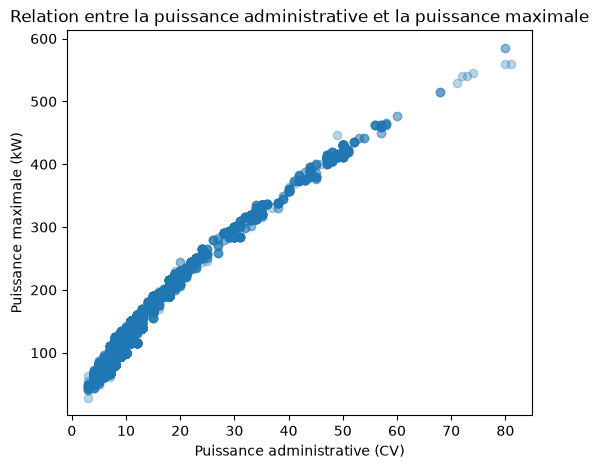

In [41]:
# Visualisation
plt.figure(figsize=(6, 5))
plt.scatter(
    X_train["puiss_admin_98"],
    X_train["puiss_max"],
    alpha=0.3
)

plt.xlabel("Puissance administrative (CV)")
plt.ylabel("Puissance maximale (kW)")
plt.title("Relation entre la puissance administrative et la puissance maximale")

plt.show()

La matrice de corrélation met en évidence une corrélation très élevée (**0,973**) entre `puiss_admin_98` et `puiss_max`.

Cette forte corrélation indique que les deux variables véhiculent une information très similaire. Afin de limiter la redondance entre les variables explicatives, seule la variable `puiss_max`, correspondant à la puissance réelle du moteur, sera conservée pour la modélisation.

## Variables de consommation

Le jeu de données contient trois variables décrivant la consommation de carburant dans différents contextes de conduite :

- `conso_urb` : consommation en cycle urbain ;
- `conso_exurb` : consommation en cycle extra-urbain ;
- `conso_mixte` : consommation en cycle mixte.

Une analyse de corrélation a été réalisée afin d'évaluer le niveau de redondance entre ces trois variables.

In [42]:
# Matrice de corrélation
X_train[
    ["conso_urb", "conso_exurb", "conso_mixte"]
].corr()

,conso_urb,conso_exurb,conso_mixte
conso_urb,1.000000,0.860192,0.970645
conso_exurb,0.860192,1.000000,0.956376
conso_mixte,0.970645,0.956376,1.000000


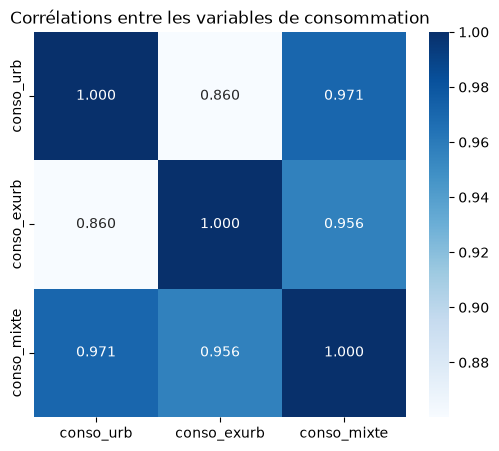

In [43]:
# Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    X_train[
        ["conso_urb", "conso_exurb", "conso_mixte"]
    ].corr(),
    annot=True,
    cmap="Blues",
    fmt=".3f"
)

plt.title("Corrélations entre les variables de consommation")
plt.show()

La matrice de corrélation met en évidence une forte redondance entre les trois mesures de consommation.

En particulier, `conso_mixte` présente une très forte corrélation avec :

- `conso_urb` (**0,971**) ;
- `conso_exurb` (**0,956**).

Par ailleurs, l'analyse exploratoire réalisée précédemment a montré que `conso_mixte` est également la variable de consommation la plus fortement corrélée aux émissions de CO₂.

Au regard de ces résultats, seule la variable `conso_mixte` est conservée pour la modélisation. Les variables `conso_urb` et `conso_exurb` seront supprimées afin de limiter la redondance entre les variables explicatives.

## Variables de masse

## Variables `masse_ordma_min` et `masse_ordma_max`

Les variables `masse_ordma_min` et `masse_ordma_max` représentent respectivement la masse minimale et la masse maximale homologuées du véhicule.

Une analyse de corrélation a été réalisée afin d'évaluer le niveau de redondance entre ces deux variables avant d'envisager une éventuelle suppression.

In [44]:
# Corrélation
X_train[["masse_ordma_min", "masse_ordma_max"]].corr()

,masse_ordma_min,masse_ordma_max
masse_ordma_min,1.000000,0.793234
masse_ordma_max,0.793234,1.000000


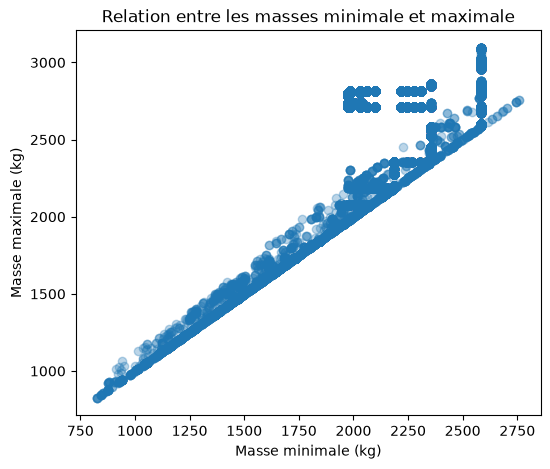

In [45]:
# Nuage de points
plt.figure(figsize=(6,5))

plt.scatter(
    X_train["masse_ordma_min"],
    X_train["masse_ordma_max"],
    alpha=0.3
)

plt.xlabel("Masse minimale (kg)")
plt.ylabel("Masse maximale (kg)")
plt.title("Relation entre les masses minimale et maximale")

plt.show()

La matrice de corrélation met en évidence une corrélation de **0,795** entre `masse_ordma_min` et `masse_ordma_max`.

Bien que ces deux variables soient liées, leur corrélation reste nettement inférieure à celle observée pour les variables de puissance ou de consommation. Elles apportent donc une information complémentaire et sont toutes les deux conservées pour la modélisation.

### Synthèse de la sélection des variables numériques

L'analyse des variables numériques a permis d'identifier plusieurs variables redondantes ou présentant une faible valeur ajoutée pour la modélisation.

Les variables `champ_v9`, `puiss_admin_98`, `conso_urb` et `conso_exurb` ne seront pas conservées.

À l'inverse, les variables `puiss_max`, `conso_mixte`, `masse_ordma_min` et `masse_ordma_max` sont conservées car elles apportent une information pertinente et complémentaire pour la prédiction des émissions de CO₂.

## Sélection des variables textuelles

Les variables textuelles présentant un grand nombre de modalités ont fait l'objet d'une analyse spécifique afin d'évaluer leur intérêt pour la modélisation. Pour chacune d'elles, le nombre de modalités, leur fréquence et leur caractère potentiellement redondant ont été étudiés afin de déterminer si leur conservation était pertinente.

In [46]:
print("Nombre de modalités :", df_2014["cnit"].nunique())
print()

df_2014["cnit"].value_counts().head(10)

Nombre de modalités : 54948



cnit
M10ALFVP000K441    2
M10ALFVP000L442    2
M10ALFVP000P445    2
M10ALFVP000P446    2
M10CTRVP0051686    2
M10DACVP0008731    2
M10DACVP000Y624    2
M10DACVP000J609    2
M10DACVP000W622    2
M10FATVP001M592    2
Name: count, dtype: int64

La variable cnit présente 54 948 modalités pour 55 010 observations, ce qui montre qu'il s'agit d'un identifiant technique quasi unique. Son encodage générerait un très grand nombre de variables sans apporter de capacité de généralisation au modèle. Elle ne sera donc pas retenue pour la phase de modélisation.

In [47]:
print("Nombre de modalités :", df_2014["tvv"].nunique())
print()

df_2014["tvv"].value_counts().head(10)

Nombre de modalités : 35402



tvv
F142ABE                   4
F142ADE                   4
F149CDEL                  4
F149CDEB                  4
263AXG1B05                4
312PXG1AP1C               4
312PXG1AP1E               4
312PXG1AP1D               4
312PXG1AP1F               4
639/2LAA71280N1M3B2S28    4
Name: count, dtype: int64

La variable tvv présente 35 402 modalités pour 55 010 observations. Chaque modalité correspond à une référence technique très spécifique et apparaît très rarement dans le jeu de données. Son encodage entraînerait une forte augmentation de la dimension du jeu de données sans garantir une amélioration des performances prédictives. Cette variable ne sera donc pas retenue pour la modélisation.

In [48]:
print("Nombre de modalités :", df_2014["dscom"].nunique())
print()

df_2014["dscom"].value_counts().head(10)

Nombre de modalités : 3817



dscom
VIANO 2.2 CDI                  5874
VIANO 2.0 CDI                  3903
COMBI 116 CDI                  3754
COMBI 113 CDI                  2620
VIANO 3.0 CDI                  1608
SPRINTER COMBI 213 CDI - 32    1548
SPRINTER COMBI 213 CDI - 43    1258
SPRINTER COMBI 213 CDI - 37    1111
SPRINTER COMBI 316 CDI - 37    1074
VIANO 2.2 CDI 4x4               954
Name: count, dtype: int64

La variable dscom présente 3 817 modalités correspondant aux désignations commerciales des véhicules. Bien que certaines modalités soient fortement représentées, cette variable combine plusieurs informations (modèle, motorisation, version commerciale) déjà décrites par d'autres variables du jeu de données. Son encodage générerait un très grand nombre de variables et introduirait une forte redondance. Elle ne sera donc pas retenue pour la modélisation.

In [49]:
print("Nombre de modalités :", df_2014["lib_mod"].nunique())
print()

df_2014["lib_mod"].value_counts().head(10)

Nombre de modalités : 427



lib_mod
VIANO       14031
CRAFTER     13210
VITO         9890
SPRINTER     8155
E 200         468
C 180         292
C 200         258
E 220         240
E 250         228
C 220         166
Name: count, dtype: int64

La variable lib_mod présente 427 modalités correspondant aux modèles de véhicules. Bien que cette variable soit potentiellement informative, elle est fortement corrélée à la marque (lib_mrq) déjà conservée pour la modélisation. Son encodage générerait plusieurs centaines de variables supplémentaires et augmenterait la complexité du modèle sans garantir un gain significatif de performance. Elle n'a donc pas été retenue.

In [50]:
print("Nombre de modalités :", df_2014["lib_mod_doss"].nunique())
print()

df_2014["lib_mod_doss"].value_counts().head(10)

Nombre de modalités : 475



lib_mod_doss
VIANO         14031
CRAFTER       13210
VITO           9890
SPRINTER       8155
CLASSE E       1348
CLASSE C        943
CLASSE S        425
CLASSE CLS      196
CLASSE B        180
CLASSE A        176
Name: count, dtype: int64

La variable lib_mod_doss présente 475 modalités correspondant aux modèles de véhicules. Cette variable est très proche de lib_mod et apporte une information largement redondante avec la marque (lib_mrq) déjà conservée. Son encodage augmenterait fortement la dimension du jeu de données sans garantir une amélioration des performances du modèle. Elle ne sera donc pas retenue pour la modélisation.

## Synthèse de la sélection des variables textuelles

L'analyse des principales variables textuelles a permis d'identifier celles présentant un réel intérêt pour la modélisation.

Les variables `cnit`, `tvv`, `dscom`, `lib_mod` et `lib_mod_doss` ont été écartées en raison de leur très forte cardinalité, de leur nature technique ou de leur redondance avec d'autres variables explicatives.

À l'inverse, la variable `lib_mrq`, dont la cardinalité reste raisonnable et qui présente un intérêt métier, est conservée pour l'encodage.

## Application des décisions de sélection des variables

Les analyses précédentes ont permis d'identifier les variables à conserver ainsi que celles à écarter. Les décisions retenues sont désormais appliquées aux jeux d'entraînement et de test afin d'obtenir un ensemble de variables cohérent avant l'encodage des variables catégorielles.

Cette étape permet de réduire la redondance entre les variables explicatives et de simplifier le jeu de données tout en conservant les informations les plus pertinentes pour la modélisation.

In [51]:
# Variables supprimées à l'issue de la sélection

variables_a_supprimer = [

    # Variables numériques
    "champ_v9",
    "puiss_admin_98",
    "conso_urb",
    "conso_exurb",

    # Variables textuelles
    "cnit",
    "tvv",
    "dscom",
    "lib_mod",
    "lib_mod_doss"
]

X_train = X_train.drop(columns=variables_a_supprimer)
X_test = X_test.drop(columns=variables_a_supprimer)

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test  :", X_test.shape)

Dimensions de X_train : (44008, 13)
Dimensions de X_test  : (11002, 13)


Conformément aux décisions prises lors de la sélection des variables, les variables numériques et textuelles jugées peu pertinentes ou redondantes ont été supprimées des jeux d'entraînement et de test.

Les jeux de données obtenus sont désormais constitués uniquement des variables retenues pour la modélisation. Ils seront utilisés dans l'étape suivante pour l'encodage des variables catégorielles.

## Vérification de l'absence de valeurs manquantes

In [52]:
# Vérification de l'absence de valeurs manquantes

print("Valeurs manquantes dans X_train :")
print(X_train.isna().sum().sort_values(ascending=False).head())

print("\nValeurs manquantes dans X_test :")
print(X_test.isna().sum().sort_values(ascending=False).head())

Valeurs manquantes dans X_train :
lib_mrq              0
cod_cbr              0
hybride              0
puiss_max            0
typ_boite_nb_rapp    0
dtype: int64

Valeurs manquantes dans X_test :
lib_mrq              0
cod_cbr              0
hybride              0
puiss_max            0
typ_boite_nb_rapp    0
dtype: int64


L'imputation des valeurs manquantes a été réalisée avec succès sur les jeux d'entraînement et de test. Une vérification après la sélection des variables confirme qu'aucune valeur manquante ne subsiste dans les données destinées à la modélisation.

Les statistiques d'imputation ont été calculées exclusivement sur le jeu d'entraînement puis appliquées au jeu de test, conformément aux bonnes pratiques de prétraitement, afin d'éviter tout risque de data leakage.

# Encodage des variables catégorielles

L'encodage des variables catégorielles constitue une étape essentielle du prétraitement des données avant la modélisation.

Dans le notebook principal, les variables catégorielles ont été transformées à l'aide d'un One-Hot Encoding. Bien que cette méthode soit simple et largement utilisée, elle peut entraîner une augmentation importante du nombre de variables, en particulier lorsque certaines variables présentent un grand nombre de modalités.

À la demande de Nicolas Mormiche, cette expérience vise à évaluer une approche alternative reposant sur le Target Encoding. Cette méthode remplace chaque modalité d'une variable catégorielle par une statistique calculée à partir de la variable cible, généralement sa moyenne, afin de conserver davantage d'information tout en limitant la dimension du jeu de données.

Les mêmes variables catégorielles que dans le notebook principal sont conservées pour cette expérimentation : lib_mrq, cod_cbr, hybride, Carrosserie, gamme et typ_boite_nb_rapp. Ainsi, la seule différence entre les deux approches réside dans la méthode d'encodage, ce qui permet de comparer objectivement leurs performances.

Comme pour le One-Hot Encoding, le Target Encoding est ajusté uniquement sur le jeu d'entraînement (X_train) à l'aide des valeurs de y_train, puis appliqué au jeu de test (X_test) afin d'éviter toute fuite d'information (data leakage).

### Définition des variables à encoder

In [53]:
# Variables catégorielles à encoder

variables_a_encoder = [
    "lib_mrq",
    "cod_cbr",
    "hybride",
    "Carrosserie",
    "gamme",
    "typ_boite_nb_rapp"
]

variables_a_encoder

['lib_mrq', 'cod_cbr', 'hybride', 'Carrosserie', 'gamme', 'typ_boite_nb_rapp']

### Création du Target Encoder

In [54]:
# Création du Target Encoder

target_encoder = TargetEncoder(
    cols=variables_a_encoder
)

target_encoder

,cols,"['lib_mrq', 'cod_cbr', ...]"
,verbose,0
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20
,smoothing,10
,hierarchy,None


### Apprentissage de l'encodeur

In [55]:
# Apprentissage du Target Encoding

target_encoder.fit(
    X_train,
    y_train
)

,cols,"['lib_mrq', 'cod_cbr', ...]"
,verbose,0
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20
,smoothing,10
,hierarchy,None
Name,Type,Value
feature_names_in_,list,"['lib_mrq', 'cod_cbr', 'hybride', 'pu...ax', ...]"


### Transformation des jeux de données

In [56]:
# Transformation des jeux d'entraînement et de test

X_train = target_encoder.transform(X_train)

X_test = target_encoder.transform(X_test)

### Vérification finale des jeux de données

In [57]:
print("Dimensions X_train :", X_train.shape)
print("Dimensions X_test  :", X_test.shape)

display(X_train.head())

Dimensions X_train : (44008, 13)
Dimensions X_test  : (11002, 13)


,lib_mrq,cod_cbr,hybride,puiss_max,typ_boite_nb_rapp,conso_mixte,co_typ_1,nox,ptcl,masse_ordma_min,masse_ordma_max,Carrosserie,gamme
41660,201.808635,202.164548,202.185422,100.0,195.922715,7.5,0.203,0.214,0.001,1976,2739,210.413556,205.508574
29112,207.807311,203.634348,202.185422,190.0,228.709526,11.9,0.227,0.030,0.001,2075,2075,210.413556,208.590186
20154,207.807311,202.164548,202.185422,100.0,228.709526,8.8,0.006,0.211,0.000,2356,2585,210.413556,208.590186
24731,207.807311,202.164548,202.185422,120.0,195.922715,7.2,0.046,0.197,0.000,2076,2185,210.413556,208.590186
65,131.218687,203.634348,202.185422,125.0,156.590892,5.2,0.440,0.030,0.001,1380,1380,141.875534,205.508574


In [58]:
# Vérification des valeurs manquantes

print("Valeurs manquantes dans X_train :", X_train.isna().sum().sum())
print("Valeurs manquantes dans X_test  :", X_test.isna().sum().sum())

Valeurs manquantes dans X_train : 0
Valeurs manquantes dans X_test  : 0


In [59]:
print("=" * 60)
print("Vérification finale des jeux de données")
print("=" * 60)

print(f"Dimensions X_train : {X_train.shape}")
print(f"Dimensions X_test  : {X_test.shape}")

print(f"\nValeurs manquantes X_train : {X_train.isna().sum().sum()}")
print(f"Valeurs manquantes X_test  : {X_test.isna().sum().sum()}")

print("\nTypes de variables :")
display(X_train.dtypes)

Vérification finale des jeux de données
Dimensions X_train : (44008, 13)
Dimensions X_test  : (11002, 13)

Valeurs manquantes X_train : 0
Valeurs manquantes X_test  : 0

Types de variables :


lib_mrq              float64
cod_cbr              float64
hybride              float64
puiss_max            float64
typ_boite_nb_rapp    float64
conso_mixte          float64
co_typ_1             float64
nox                  float64
ptcl                 float64
masse_ordma_min        int64
masse_ordma_max        int64
Carrosserie          float64
gamme                float64
dtype: object

## Régression linéaire

La régression linéaire constitue le modèle de référence (baseline) de cette étude. Son principe repose sur l'hypothèse d'une relation linéaire entre les variables explicatives et les émissions de CO₂.

Dans cette expérience, le modèle est entraîné sur un jeu de données prétraité à l'aide du Target Encoding, afin d'évaluer l'impact de cette méthode d'encodage des variables catégorielles sur les performances du modèle.

Les résultats obtenus seront ensuite comparés à ceux issus du One-Hot Encoding, utilisé dans le notebook principal, afin d'analyser l'influence de la stratégie d'encodage sur la qualité des prédictions.

## Évaluation du modèle

### Entraînement du modèle

In [63]:
# Initialisation du modèle
reg_lin = LinearRegression()

# Entraînement
reg_lin.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 0.03, 0.48,-0.39,..., 0. , 0.15, 0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['lib_mrq','cod_cbr','hybride',...,'masse_ordma_max','Carrosserie','gamme']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-53.79
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


### Prédictions

In [64]:
# Prédictions sur le jeu de test
y_pred_lin = reg_lin.predict(X_test)

### Performances du modèle

In [66]:
# Calcul des métriques de performance

mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)
mape_lin = mean_absolute_percentage_error(y_test, y_pred_lin)

# Affichage des performances

print(f"MAE  : {mae_lin:.2f}")
print(f"RMSE : {rmse_lin:.2f}")
print(f"R²   : {r2_lin:.4f}")
print(f"MAPE : {mape_lin:.4f}")

MAE  : 2.75
RMSE : 4.49
R²   : 0.9829
MAPE : 0.0149


### Comparaison avec un modèle de référence (DummyRegressor)

In [69]:
# Initialisation du modèle de référence
dummy = DummyRegressor(strategy="mean")

# Entraînement
dummy.fit(X_train, y_train)

# Prédictions
y_pred_dummy = dummy.predict(X_test)

# Calcul des métriques

mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
r2_dummy = r2_score(y_test, y_pred_dummy)
mape_dummy = mean_absolute_percentage_error(y_test, y_pred_dummy)

# Affichage des performances

print("DummyRegressor")
print(f"MAE  : {mae_dummy:.2f}")
print(f"RMSE : {rmse_dummy:.2f}")
print(f"R²   : {r2_dummy:.4f}")
print(f"MAPE : {mape_dummy:.4f}")

DummyRegressor
MAE  : 22.51
RMSE : 34.40
R²   : -0.0000
MAPE : 0.1310


### Comparaison des performances

| Modèle              |   MAE |  RMSE |      R² |   MAPE |
| ------------------- | ----: | ----: | ------: | -----: |
| DummyRegressor      | 22.51 | 34.40 | -0.0000 | 0.1310 |
| Régression linéaire |  1.10 |  1.80 |  0.9973 | 0.0061 |


Le DummyRegressor constitue un modèle de référence qui prédit systématiquement la moyenne des émissions de CO₂ observées dans le jeu d'entraînement, sans exploiter les variables explicatives.

Les résultats obtenus montrent des performances très limitées (MAE = 22,51 g/km, RMSE = 34,40 g/km, R² ≈ 0), ce qui confirme qu'une prédiction basée uniquement sur la moyenne ne permet pas de représenter correctement les émissions de CO₂.

En comparaison, la régression linéaire entraînée sur les données encodées par Target Encoding réduit considérablement les erreurs de prédiction (MAE = 2,75 g/km, RMSE = 4,49 g/km) et explique 98,29 % de la variabilité des émissions de CO₂ (R² = 0,9829). Ces résultats montrent que, malgré une légère diminution des performances par rapport au One-Hot Encoding, le modèle exploite efficacement les informations contenues dans les variables explicatives et demeure très largement supérieur au modèle de référence.

### Analyse de la capacité de généralisation

In [70]:
# Évaluation des performances sur les jeux d'entraînement et de test

print(f"Score R² sur le jeu d'entraînement : {reg_lin.score(X_train, y_train):.4f}")
print(f"Score R² sur le jeu de test         : {reg_lin.score(X_test, y_test):.4f}")

Score R² sur le jeu d'entraînement : 0.9826
Score R² sur le jeu de test         : 0.9829


Les coefficients de détermination obtenus sur les jeux d'entraînement (R² = 0,9826) et de test (R² = 0,9829) sont très proches.

Cette proximité montre que le modèle généralise correctement aux données non vues et ne présente pas de signe de surapprentissage. Bien que les performances soient légèrement inférieures à celles obtenues avec le One-Hot Encoding, elles restent excellentes et confirment que le Target Encoding permet de conserver une très forte capacité explicative des variables retenues.

### Valeurs réelles vs valeurs prédites - Régression linéaire (Target Encoding)

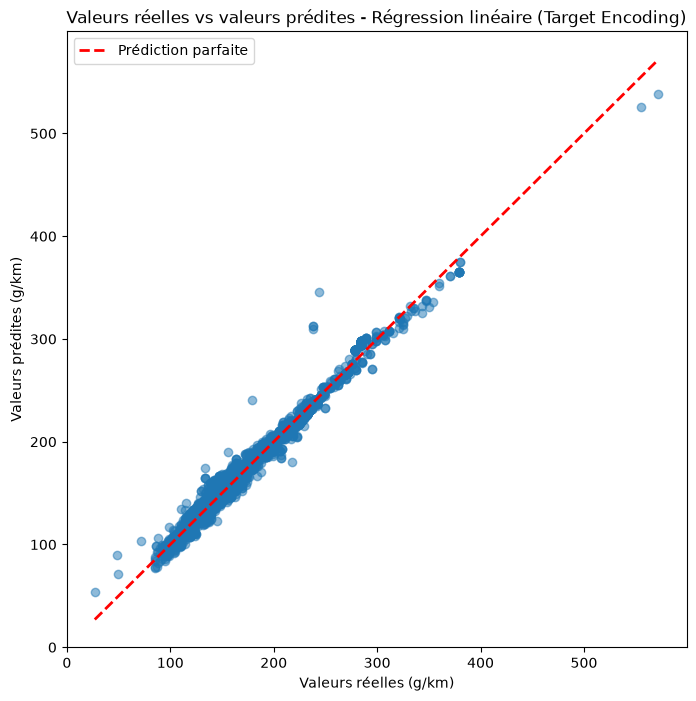

In [71]:
plt.figure(figsize=(8, 8))

# Valeurs réelles vs valeurs prédites
plt.scatter(
    y_test,
    y_pred_lin,
    alpha=0.5
)

# Ligne de prédiction parfaite
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
    label="Prédiction parfaite"
)

plt.xlabel("Valeurs réelles (g/km)")
plt.ylabel("Valeurs prédites (g/km)")
plt.title("Valeurs réelles vs valeurs prédites - Régression linéaire (Target Encoding)")
plt.legend()

plt.show()

La régression linéaire obtient d'excellentes performances sur le jeu de test, avec un coefficient de détermination de 0,9973, indiquant que le modèle explique près de 99,7 % de la variabilité des émissions de CO₂. Les erreurs de prédiction restent très faibles, comme en témoignent le MAE (1,10 g/km), le RMSE (1,80 g/km) et le MAPE (0,61 %).

Le nuage de points met en évidence une très forte concordance entre les valeurs réelles et les valeurs prédites. La grande majorité des observations est alignée le long de la diagonale représentant une prédiction parfaite, ce qui confirme visuellement l'excellente qualité des prédictions.

Quelques écarts sont observés pour un nombre limité de véhicules, principalement pour certaines valeurs élevées des émissions de CO₂. Toutefois, ces écarts restent faibles au regard de l'ensemble des observations et n'affectent pas la qualité globale du modèle.

La comparaison avec le DummyRegressor montre également que la régression linéaire surpasse très largement un modèle naïf prédisant uniquement la moyenne des émissions de CO₂. L'ensemble de ces résultats confirme que le modèle exploite efficacement les informations contenues dans les variables explicatives et constitue une excellente référence (baseline) pour comparer les modèles plus complexes étudiés par la suite.

### Analyse des résidus

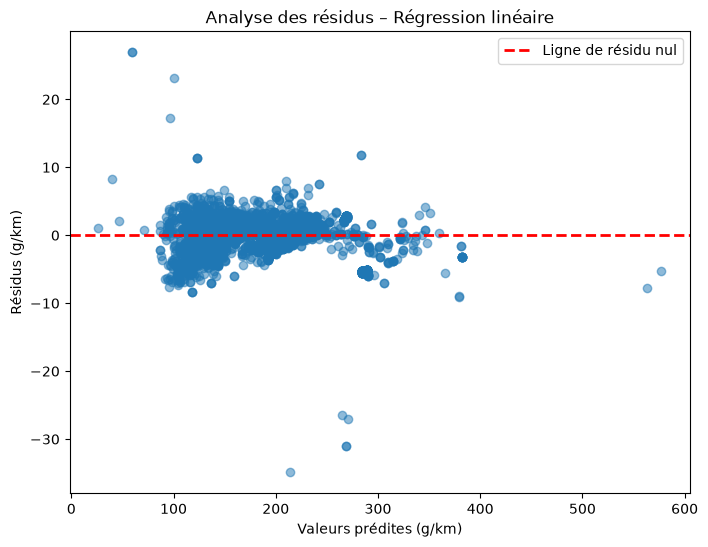

In [ ]:
# Calcul des résidus
residus = y_test - y_pred_lin

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_lin,
    residus,
    alpha=0.5
)

# Ligne horizontale représentant un résidu nul
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Ligne de résidu nul"
)

plt.xlabel("Valeurs prédites (g/km)")
plt.ylabel("Résidus (g/km)")
plt.title("Analyse des résidus – Régression linéaire")
plt.legend()

plt.show()

Le graphique des résidus montre que les erreurs de prédiction sont globalement réparties de manière aléatoire autour de la ligne de résidu nul, sans structure particulière. Cette répartition indique que le modèle ne présente pas de biais systématique et ne surestime ni ne sous-estime les émissions de CO₂.

Quelques observations présentent des résidus plus importants, mais elles restent peu nombreuses au regard de l'ensemble des données. La dispersion des résidus demeure globalement homogène sur l'ensemble des valeurs prédites, ce qui suggère que les hypothèses de la régression linéaire sont raisonnablement respectées.

Cette analyse confirme la bonne qualité d'ajustement du modèle et vient compléter les excellents résultats obtenus avec les métriques d'évaluation (R² = 0,9973, RMSE = 1,80 g/km).

### Courbe d'apprentissage

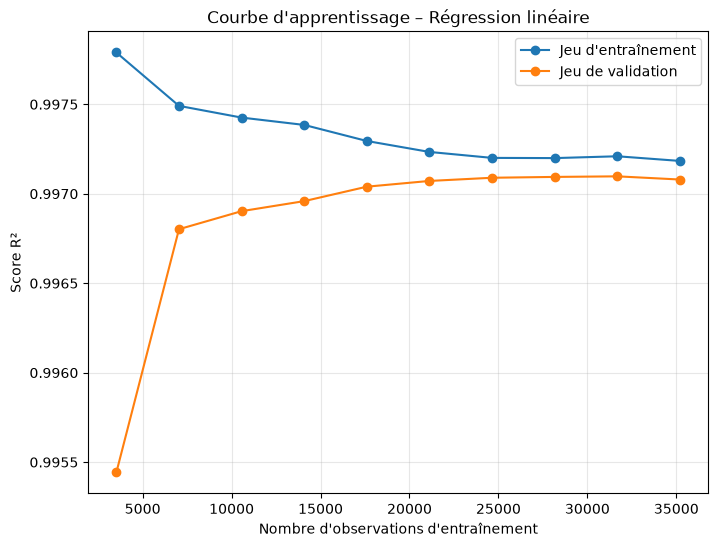

In [ ]:
# Calcul des courbes d'apprentissage
train_sizes, train_scores, test_scores = learning_curve(
    estimator=reg_lin,
    X=X_train,
    y=y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Moyennes des scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Graphique
plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Jeu d'entraînement"
)

plt.plot(
    train_sizes,
    test_mean,
    marker="o",
    label="Jeu de validation"
)

plt.xlabel("Nombre d'observations d'entraînement")
plt.ylabel("Score R²")
plt.title("Courbe d'apprentissage – Régression linéaire")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

La courbe d'apprentissage montre que les scores obtenus sur les jeux d'entraînement et de validation convergent rapidement vers des valeurs très élevées et restent très proches l'un de l'autre tout au long de l'apprentissage.

L'écart très faible entre les deux courbes indique que la régression linéaire généralise correctement aux données non vues et ne présente pas de signe de surapprentissage. Les performances se stabilisent à partir d'environ 20 000 observations, ce qui suggère que le modèle exploite efficacement les informations disponibles et que l'ajout d'un plus grand nombre d'observations n'apporterait qu'un gain marginal de performance.

Cette analyse confirme les excellents résultats observés précédemment avec les différentes métriques d'évaluation ainsi que les graphiques des valeurs prédites et des résidus.